# Finding pilot patient

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from results_functions import extract_ews, extract_tws, grand_average, plot_all_patients
from db import patients_db


In [2]:
# Combine ews for all patients
strategy = "transfer"
ews_all_patients = dict()

for id in patients_db:

    info = patients_db.get(id)
    patient = info.get('patient_nr')
    last_session = info.get('last_session')
    calibration_selection = info.get('selection')

    print("patient: ", patient)
    print("last session", last_session)
    print("calibration_selection", calibration_selection)

    with open(f'p{patient}_performances_v1.pkl', 'rb') as f:
        performances_new = pickle.load(f)    

        
    ews_transfer_slda, ews_transfer_btlda = extract_ews(performances_new, patient, last_session-1, strategy=strategy)
    #tws_transfer_slda_08_06, tws_transfer_btlda_08_06 = extract_tws_transfer_08_06(performances_new, patient, last_session-1)

    ews_all_patients.update({f"p{patient}": (ews_transfer_slda, ews_transfer_btlda)})

ews_btlda_all_combined = []

for idx,p in enumerate(ews_all_patients):
    ews_btlda_all_combined.append(ews_all_patients.get(f'p{idx+1}')[1])

patient:  1
last session 18
calibration_selection 6D_long_350
Extracting from performances with the following keys: 
dict_keys(['p1_transfer_s3', 'p1_transfer_s4', 'p1_transfer_s5', 'p1_transfer_s6', 'p1_transfer_s7', 'p1_transfer_s8', 'p1_transfer_s9', 'p1_transfer_s10', 'p1_transfer_s11', 'p1_transfer_s12', 'p1_transfer_s13', 'p1_transfer_s14', 'p1_transfer_s15', 'p1_transfer_s16', 'p1_transfer_s17'])
strategy: transfer
patient:  2
last session 14
calibration_selection 6D_long_350
Extracting from performances with the following keys: 
dict_keys(['p2_transfer_s3', 'p2_transfer_s4', 'p2_transfer_s5', 'p2_transfer_s6', 'p2_transfer_s7', 'p2_transfer_s8', 'p2_transfer_s9', 'p2_transfer_s10', 'p2_transfer_s11', 'p2_transfer_s12', 'p2_transfer_s13'])
strategy: transfer
patient:  3
last session 17
calibration_selection 6D_short_250
Extracting from performances with the following keys: 
dict_keys(['p3_transfer_s3', 'p3_transfer_s4', 'p3_transfer_s5', 'p3_transfer_s6', 'p3_transfer_s7', 'p3_t

In [22]:
print(ews_all_patients.get('p1')[0])

[0.58512851 0.67857181 0.70415939 0.72186223 0.79821625 0.79723387
 0.80215574 0.86061124 0.86490822 0.86813733 0.88900019 0.90192898
 0.896366   0.88515811 0.90630158]


In [ ]:


# Get grand average       
sessions = grand_average(ews_btlda_all_combined)


session:  0
adding element (patient 1): 0.5842798307380817
adding element (patient 2): 0.5911742619518559
adding element (patient 3): 0.8010745809928992
adding element (patient 4): 0.6334604938271604
adding element (patient 5): 0.7686486059617482
adding element (patient 6): 0.7752878999444468
adding element (patient 7): 0.5740190091152014
adding element (patient 9): 0.5789493799608253
adding element (patient 10): 0.5416195703336733
averaging elements gives:  0.6498348480917658
session:  1
adding element (patient 1): 0.685339594103342
adding element (patient 2): 0.5993019111570247
adding element (patient 3): 0.8397888470228752
adding element (patient 4): 0.5804884259259259
adding element (patient 5): 0.8355180258504207
adding element (patient 6): 0.8321351446410096
adding element (patient 7): 0.5856098269628099
adding element (patient 8): 0.7757334671749329
adding element (patient 9): 0.7400405788018176
adding element (patient 10): 0.5047731075931793
averaging elements gives:  0.6978728

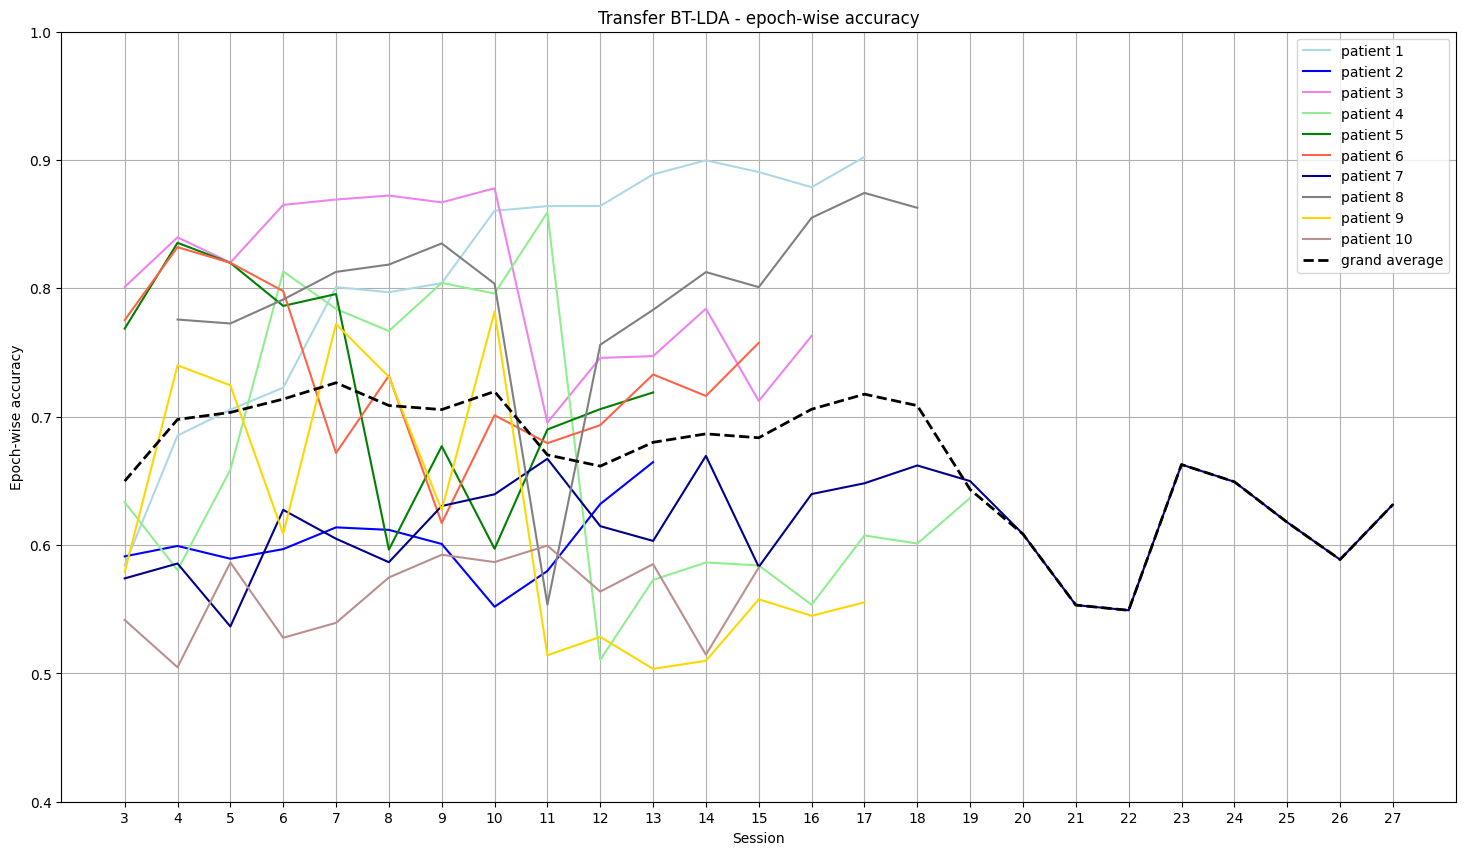

In [ ]:

plot_all_patients(ews_all_patients, grand_avg=sessions)